In [19]:
%load_ext autoreload
%autoreload 2


import pandas as pd
import numpy as np

from utils import load_data,  plot_convergence, convergence_cis, calculate_stability_metrics, bootstrap_confidence_intervals, stratified_bootstrap_ci, bootstrap_relative_instability, plot_scores_with_ci
verbose = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Convergence

## Strategies

In [ ]:
mode = "Strategy"
col="Score"

# Strategy order
strategy_order=[
    "io",
    "cot",
    "cot_sc",
    "react",
    "reflexion",
    "tot_dfs",
    "tot_bfs",
    "got",
    "rap",
    "foa"
]

# Load the data
df = load_data("../data/strategies/repeats/gpt-4.1-nano/strategies_v2.parquet", mode=mode)
df.shape

(1800, 6)

Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=10

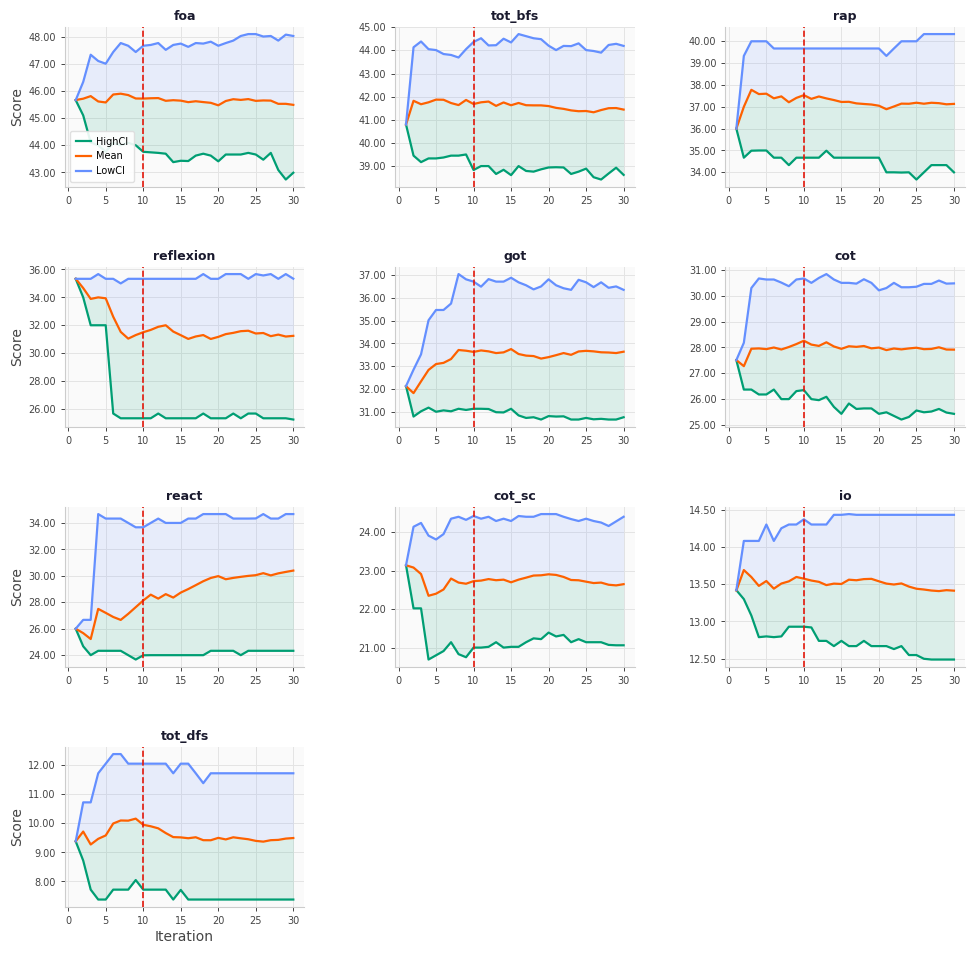

In [9]:
cis = convergence_cis(df, mode=mode, col=col, fn=np.mean)
plot_convergence(cis, savepath=f"conv_{mode}.pdf")

## Models

In [15]:
mode = "Model"
col = "Score"

model_order =[
    'deepseek-ai/DeepSeek-R1',
    'meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8',
    'gpt-4.1-mini', 
    'gpt-4.1-nano',
    'Qwen/Qwen3-235B-A22B-Thinking-2507', 
    'openai/gpt-oss-120b', 
    'gpt-5-mini',
    'gpt-5-nano',
    'claude-haiku-4-5-20251001', 
    'gemini-3-flash-preview',
    ]

# Load the data
df = load_data("../data/models/models_v2.parquet", mode=mode)
df.shape

(1745, 6)

Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=10

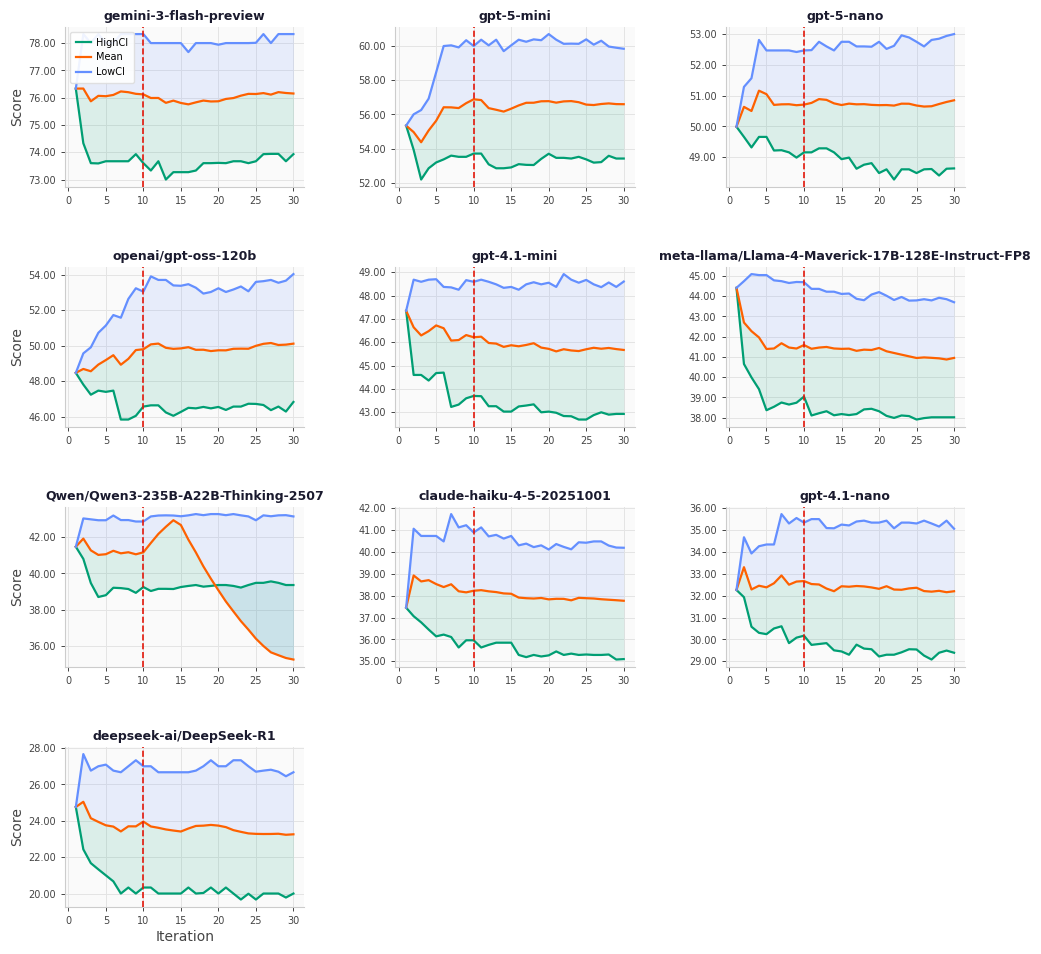

In [17]:
cis = convergence_cis(df, mode=mode, col=col, fn=np.mean)
plot_convergence(cis, savepath=f"conv_{mode}.pdf")

## Similar plots
- If you need to get the same plots but for a different metric eg. variance change the `fn` argument when using `convergence_cis`.
- If you need to get the same plots but for a different column eg. tokens or cost change the `col` argument when using `convergence_cis`.
- If you need to get the same plots but per benchmark, just filter the dataframe before computing `convergence_cis`.

# Decoding
In this section we've run some experiments investigating what happens when you change decoding parameters such as temperature, top-p, etc. In this notebook, I only show results for reasoning strategies, but we've done experiments with models as well. If you're interested in those ones then you can just change the path and also the `mode=Model` when you load the data using `load_data`.

## Temperature

### Main results

In this section we just recompute the metrics of our paper using the three different temperatures. We only do this for temperature, as we chose not to continue with these plots.

In [ ]:
mode = "Strategy"
col="Score"

# Strategy order
strategy_order=[
    "react",
    "tot_bfs",
    "foa"
]

df = load_data("../data/strategies/temperature/gpt-4.1-nano/latest.parquet", mode=mode, columns=["Temperature"])

In [27]:
df1 = df[df.Temperature==0.00].copy()
df2 = df[df.Temperature==0.35].copy()
df3 = df[df.Temperature==0.70].copy()

dfs = [df1, df2, df3]

In [28]:
tables = []
for df in dfs:
    
    # 2. Stability Analysis (Variance of Z-Scores)
    stability_df = calculate_stability_metrics(df, mode=mode, col=col)
    
    # 3. Confidence Intervals (Bootstrap)
    ci_df = bootstrap_confidence_intervals(df, mode=mode, col=col)
    
    # Run Stratified Bootstrap
    strat_ci_df = stratified_bootstrap_ci(df, mode=mode ,col=col)
    
    # Run Evaluation
    rel_instability_df = bootstrap_relative_instability(df, mode=mode, col=col)

    # --- Compile Tables ---
    raw_means = df.groupby(mode)[col].mean()
    sorted_strategies = raw_means.sort_values(ascending=False).index

    # Table 1: Performance
    table1 = pd.DataFrame({
        f"{col} (Avg)": raw_means,
        "95% CI (Stratified)": strat_ci_df["Strat_CI_Formatted"]
    }).reindex(sorted_strategies)

    # Table 2: Relative Instability
    instability_pct = (rel_instability_df["Rel_Instability_Mean"] * 100).round(2).astype(str) + "%"
    table2 = pd.DataFrame({
        "Rel. Run Instability": instability_pct,
        "95% CI (Instability)": rel_instability_df["Rel_Instability_CI"]
    }).reindex(sorted_strategies)

    # Table 3: Noise Metrics (Z-based)
    table3 = pd.DataFrame({
        "Global Noise (Z-Var)": stability_df["Global_Noise"],
        "Run Noise (Z-Var)": stability_df["Run_Noise"]
    }).reindex(sorted_strategies)

    table = pd.concat([table1, table2, table3], axis=1)
    tables.append(table)

Calculating Z-Score Variance (Stability) for 'Score'...
Bootstrapping Confidence Intervals for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Relative Instability for 'Score' (n=1000)...
Strats: ['foa' 'react' 'tot_bfs']
Calculating Z-Score Variance (Stability) for 'Score'...
Bootstrapping Confidence Intervals for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Relative Instability for 'Score' (n=1000)...
Strats: ['foa' 'react' 'tot_bfs']
Calculating Z-Score Variance (Stability) for 'Score'...
Bootstrapping Confidence Intervals for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Relative Instability for 'Score' (n=1000)...
Strats: ['foa' 'react' 'tot_bfs']


Score (Avg)                  95% CI (Stratified)                  \
              T=0.00    T=0.35 T=0.70              T=0.00          T=0.35   
Strategy                                                                    
foa         0.527333  0.516667  0.532      [49.33, 57.33]  [48.00, 55.33]   
tot_bfs     0.467333  0.491333  0.460      [42.00, 50.67]  [45.33, 52.67]   
react       0.128667  0.126000  0.130      [10.00, 16.00]  [10.67, 14.67]   

                         Rel. Run Instability                      \
                  T=0.70               T=0.00    T=0.35    T=0.70   
Strategy                                                            
foa       [47.33, 57.33]               799.4%    869.9%   988.02%   
tot_bfs   [41.33, 50.67]              1060.8%   863.38%   1707.2%   
react     [11.33, 15.33]             4225.46%  5841.16%  5434.02%   

         95% CI (Instability)                                    \
                       T=0.00           T=0.35           T=0.70   
Strategy                                                          
foa             [2.21, 16.58]    [2.48, 18.15]    [2.23, 27.02]   
tot_bfs         [1.57, 19.06]    [2.28, 20.25]    [2.24, 31.33]   
react         [22.76, 138.15]  [34.41, 191.80]  [33.85, 137.99]   

         Global Noise (Z-Var)                     Run Noise (Z-Var)            \
                       T=0.00    T=0.35    T=0.70            T=0.00    T=0.35   
Strategy                                                                        
foa                  0.916862  0.820833  0.659914          0.457686  0.347804   
tot_bfs              0.316798  0.228019  0.483781          0.272258  0.239998   
react                0.655755  0.804818  0.822241          0.301067  0.349350   

                    
            T=0.70  
Strategy            
foa       0.569275  
tot_bfs   0.348110  
react     0.343760

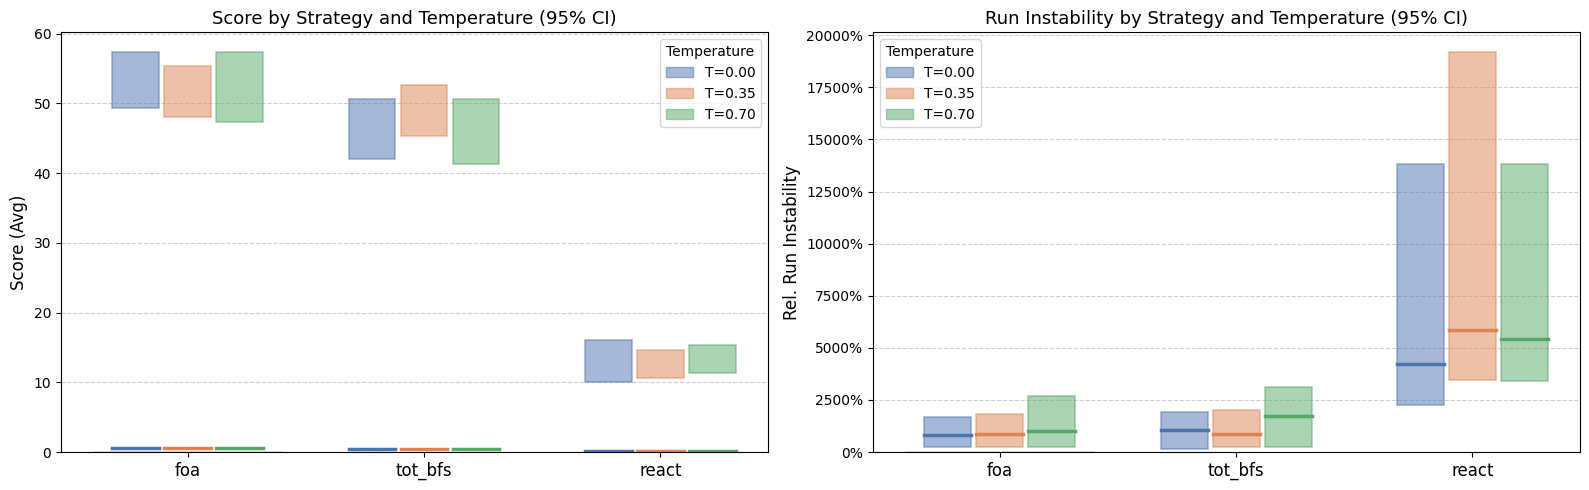

In [29]:
result = pd.concat(tables, axis=1, keys=['T=0.00', 'T=0.35', 'T=0.70'])
result = result.swaplevel(axis=1).reindex(columns=tables[0].columns, level=0)
display(result)

plot_scores_with_ci(result, "temp_strategies.pdf")

### Investigating Relative Deviation

/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_14518/1936431118.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_14518/1936431118.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_14518/1936431118.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mf

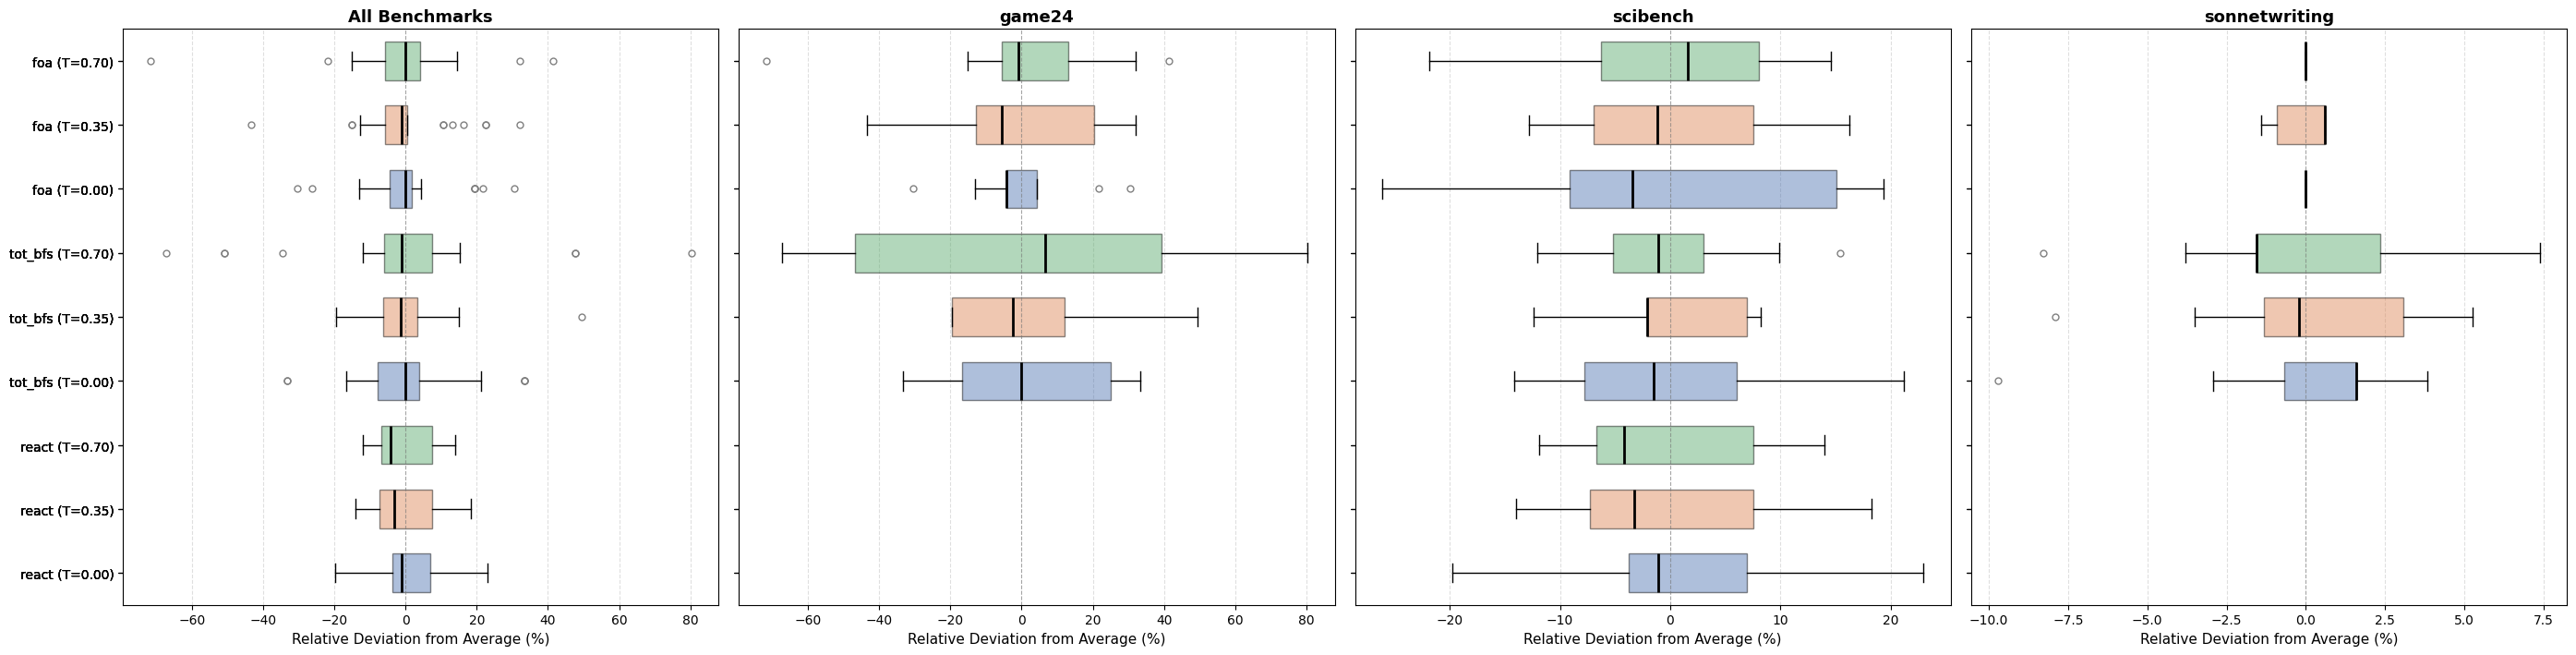

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Reload the raw data
df_strat = load_data("../data/strategies/temperature/gpt-4.1-nano/latest.parquet", mode="Strategy", columns=["Temperature"])

# Filter out groups with near-zero mean
group_means = df_strat.groupby(["Strategy", "Temperature", "Benchmark"])["Score"].transform("mean")
df_strat = df_strat[group_means > 0.05].copy()

# Compute relative deviation from average (%) per strategy-temperature-benchmark group
df_strat["Rel_Dev"] = df_strat.groupby(["Strategy", "Temperature", "Benchmark"])["Score"].transform(
    lambda x: (x - x.mean()) / x.mean() * 100
)

temps = [0.00, 0.35, 0.70]
strategies = ["react", "tot_bfs", "foa"]
colors_map = {0.00: '#4C72B0', 0.35: '#DD8452', 0.70: '#55A868'}

benchmarks = sorted(df_strat["Benchmark"].unique())
panels = ["All Benchmarks"] + benchmarks
n_panels = len(panels)

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 0.6 * len(strategies) * len(temps) + 1.8),
                         sharey=True)

if n_panels == 1:
    axes = [axes]

for idx, panel in enumerate(panels):
    ax = axes[idx]

    if panel == "All Benchmarks":
        df_panel = df_strat
    else:
        df_panel = df_strat[df_strat["Benchmark"] == panel]

    labels, data = [], []
    for s in strategies:
        for t in temps:
            mask = (df_panel["Strategy"] == s) & (df_panel["Temperature"] == t)
            vals = df_panel.loc[mask, "Rel_Dev"].values
            data.append(vals)
            labels.append(f"{s} (T={t:.2f})")

    box_colors = [colors_map[t] for s in strategies for t in temps]

    bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
                    widths=0.6,
                    flierprops=dict(marker='o', markerfacecolor='none',
                                    markeredgecolor='grey', markersize=5))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(panel, fontsize=13, fontweight='bold')
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    if idx == 0:
        ax.set_ylabel("")
    ax.set_xlabel("Relative Deviation from Average (%)", fontsize=11)

plt.tight_layout()
plt.savefig("temp_strategies_reldev.pdf")
plt.show()

## Top-p
Same as before but using different top-p values.

/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_14518/3743774295.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_14518/3743774295.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_14518/3743774295.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mf

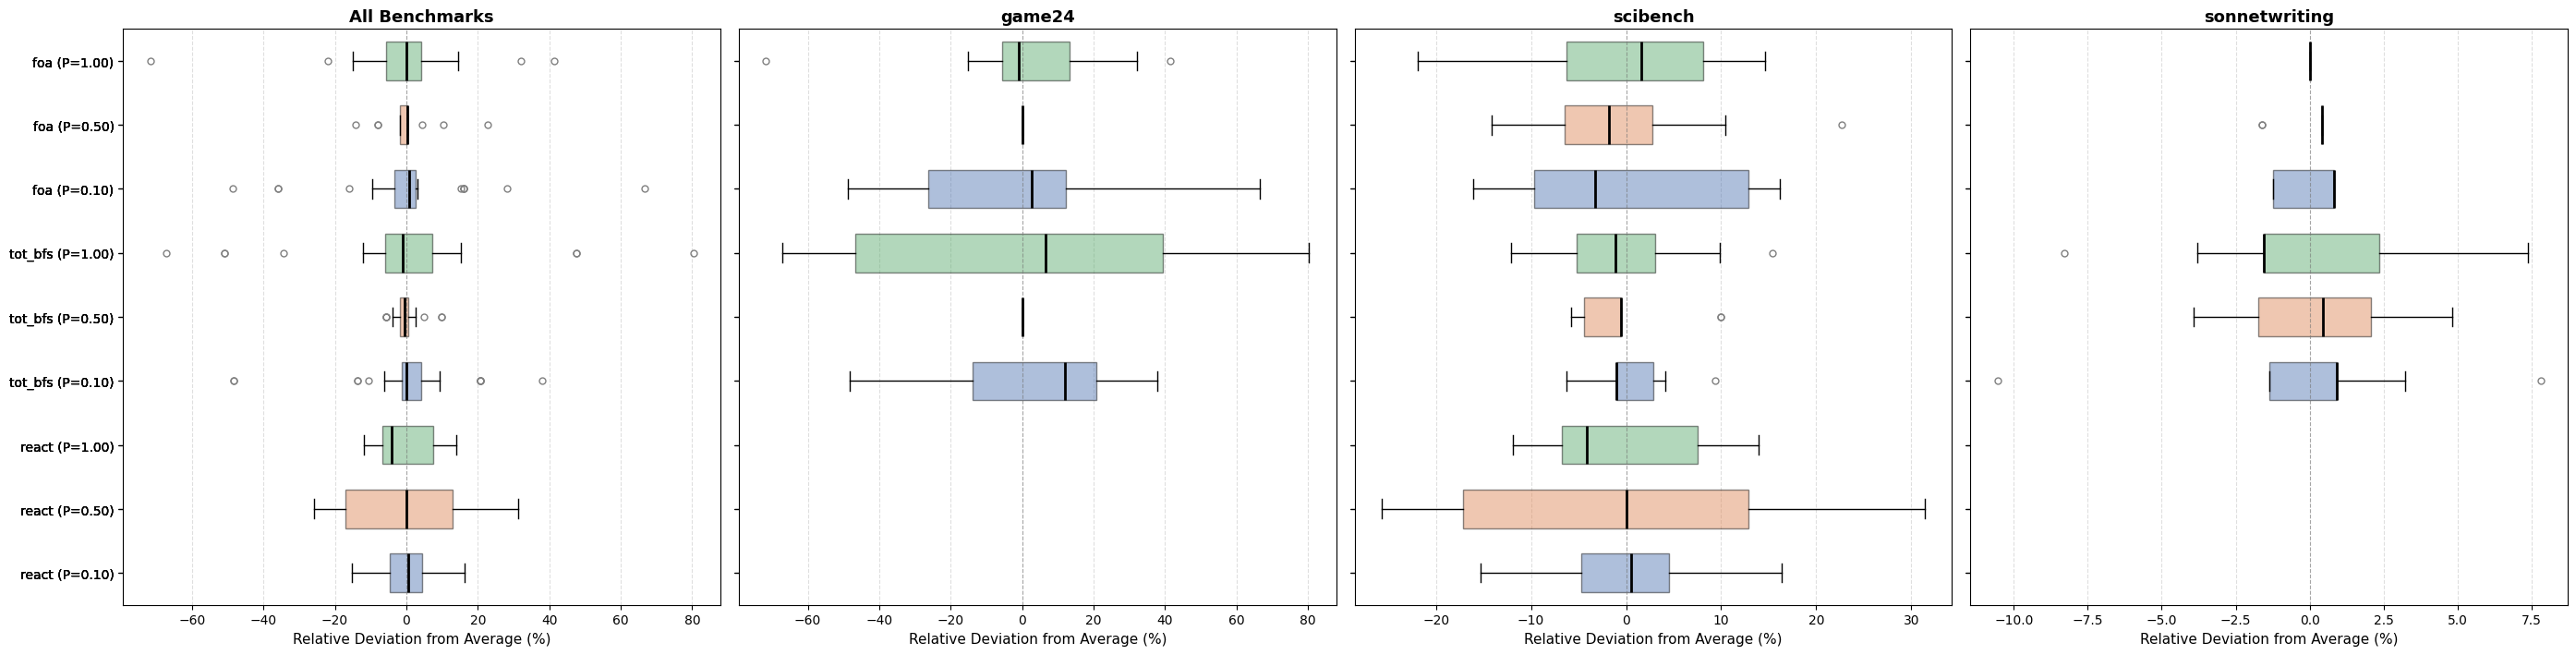

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Reload the raw data
df_strat = load_data("../data/strategies/top_p/gpt-4.1-nano/latest.parquet", mode="Strategy", columns=["Top-p"])

# Filter out groups with near-zero mean
group_means = df_strat.groupby(["Strategy", "Top-p", "Benchmark"])["Score"].transform("mean")
df_strat = df_strat[group_means > 0.05].copy()

# Compute relative deviation from average (%) per strategy-top_p-benchmark group
df_strat["Rel_Dev"] = df_strat.groupby(["Strategy", "Top-p", "Benchmark"])["Score"].transform(
    lambda x: (x - x.mean()) / x.mean() * 100
)

top_ps = sorted(df_strat["Top-p"].unique())
strategies = ["react", "tot_bfs", "foa"]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
colors_map = {p: colors[i % len(colors)] for i, p in enumerate(top_ps)}

benchmarks = sorted(df_strat["Benchmark"].unique())
panels = ["All Benchmarks"] + benchmarks
n_panels = len(panels)

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 0.6 * len(strategies) * len(top_ps) + 1.8),
                         sharey=True)

if n_panels == 1:
    axes = [axes]

for idx, panel in enumerate(panels):
    ax = axes[idx]

    if panel == "All Benchmarks":
        df_panel = df_strat
    else:
        df_panel = df_strat[df_strat["Benchmark"] == panel]

    labels, data = [], []
    for s in strategies:
        for p in top_ps:
            mask = (df_panel["Strategy"] == s) & (df_panel["Top-p"] == p)
            vals = df_panel.loc[mask, "Rel_Dev"].values
            data.append(vals)
            labels.append(f"{s} (P={p:.2f})")

    box_colors = [colors_map[p] for s in strategies for p in top_ps]

    bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
                    widths=0.6,
                    flierprops=dict(marker='o', markerfacecolor='none',
                                    markeredgecolor='grey', markersize=5))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(panel, fontsize=13, fontweight='bold')
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    if idx == 0:
        ax.set_ylabel("")
    ax.set_xlabel("Relative Deviation from Average (%)", fontsize=11)

plt.tight_layout()
plt.savefig("topp_strategies_reldev.pdf")
plt.show()

# Tests
In this section I just add the statistical tests we did to compare the distributions between different values of temperature. You can simply switch to top-p, etc. by chaning the path of the `data_path` and `columns` when you load the data using `load_data`.

In [ ]:
from scipy import stats
from itertools import combinations

def tost(group1, group2, epsilon):
    """
    Two One-Sided Tests (TOST) for equivalence.
    Returns p-value. If p < 0.05, distributions are equivalent within epsilon.
    """
    _, p1 = stats.ttest_ind(group1, group2 - epsilon)
    _, p2 = stats.ttest_ind(group1, group2 + epsilon)
    return max(p1, p2)

def chi2_test(group1, group2):
    """
    Chi-square test of independence on pass/fail counts.
    Treats scores > 0 as pass, == 0 as fail.
    Returns (chi2 statistic, p-value). If p < 0.05, distributions differ significantly.
    """
    pass1, fail1 = (group1 > 0).sum(), (group1 == 0).sum()
    pass2, fail2 = (group2 > 0).sum(), (group2 == 0).sum()
    table = np.array([[pass1, fail1], [pass2, fail2]])
    # Use Fisher's exact test if any expected count < 5
    expected = np.outer(table.sum(axis=1), table.sum(axis=0)) / table.sum()
    if (expected < 5).any():
        _, p = stats.fisher_exact(table)
        return np.nan, p
    chi2, p, _, _ = stats.chi2_contingency(table)
    return chi2, p

# --- Strategies ---
data_path = "../data/strategies/temperature/gpt-4.1-nano/latest.parquet"
columns = ["Temperature"]
df_strat_tost = load_data("../data/strategies/temperature/gpt-4.1-nano/latest.parquet", mode="Strategy", columns=columns)
# df_strat_tost.loc[df_strat_tost["Temperature"].eq(0.00), "Score"] /= 1.412345
# df_strat_tost.loc[df_strat_tost["Temperature"].eq(0.35), "Score"] /= 1.2231432

temps = [0.00, 0.35, 0.70]
strategies = ["react", "tot_bfs", "foa"]
epsilon = 0.05

# --- TOST ---
# Per benchmark
rows_bench = []
for s in strategies:
    for t1, t2 in combinations(temps, 2):
        for b in df_strat_tost["Benchmark"].unique():
            g1 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t1) & (df_strat_tost.Benchmark==b)]["Score"].values
            g2 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t2) & (df_strat_tost.Benchmark==b)]["Score"].values
            if len(g1) > 1 and len(g2) > 1:
                p = tost(g1, g2, epsilon)
                rows_bench.append({"Strategy": s, "Benchmark": b, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                                   "Mean_Diff": round(g1.mean() - g2.mean(), 4), "TOST_p": round(p, 4),
                                   "Equivalent": p < 0.05})

tost_strat_bench_df = pd.DataFrame(rows_bench)

# Whole distribution
rows_all = []
for s in strategies:
    for t1, t2 in combinations(temps, 2):
        g1 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t1)]["Score"].values
        g2 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t2)]["Score"].values
        if len(g1) > 1 and len(g2) > 1:
            p = tost(g1, g2, epsilon)
            rows_all.append({"Strategy": s, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                             "Mean_Diff": round(g1.mean() - g2.mean(), 4), "TOST_p": round(p, 4),
                             "Equivalent": p < 0.05})

tost_strat_all_df = pd.DataFrame(rows_all)

print("=== TOST: Per Benchmark ===")
display(tost_strat_bench_df)
print("\n=== TOST: All Benchmarks Pooled ===")
display(tost_strat_all_df)

# --- Chi-Square ---
# Per benchmark
rows_bench = []
for s in strategies:
    for t1, t2 in combinations(temps, 2):
        for b in df_strat_tost["Benchmark"].unique():
            g1 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t1) & (df_strat_tost.Benchmark==b)]["Score"].values
            g2 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t2) & (df_strat_tost.Benchmark==b)]["Score"].values
            if len(g1) > 1 and len(g2) > 1:
                chi2, p = chi2_test(g1, g2)
                rows_bench.append({"Strategy": s, "Benchmark": b, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                                   "Chi2": round(chi2, 4) if not np.isnan(chi2) else "Fisher",
                                   "Chi2_p": round(p, 4), "Significant": p < 0.05, "Different": p < 0.05})

chi2_strat_bench_df = pd.DataFrame(rows_bench)

# Whole distribution
rows_all = []
for s in strategies:
    for t1, t2 in combinations(temps, 2):
        g1 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t1)]["Score"].values
        g2 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t2)]["Score"].values
        if len(g1) > 1 and len(g2) > 1:
            chi2, p = chi2_test(g1, g2)
            rows_all.append({"Strategy": s, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                             "Chi2": round(chi2, 4) if not np.isnan(chi2) else "Fisher",
                             "Chi2_p": round(p, 4), "Significant": p < 0.05, "Different": p < 0.05})

chi2_strat_all_df = pd.DataFrame(rows_all)

print("\n=== Chi-Square: Per Benchmark ===")
display(chi2_strat_bench_df)
print("\n=== Chi-Square: All Benchmarks Pooled ===")
display(chi2_strat_all_df)

=== TOST: Per Benchmark ===


/Users/nearchospotamitis/opt/anaconda3/envs/CacheSaver/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,Strategy,Benchmark,Pair,Mean_Diff,TOST_p,Equivalent
0,react,game24,T=0.00 vs T=0.35,0.006,0.0000,True
1,react,scibench,T=0.00 vs T=0.35,0.002,0.0180,True
2,react,sonnetwriting,T=0.00 vs T=0.35,0.000,0.0000,True
3,react,game24,T=0.00 vs T=0.70,0.008,0.0000,True
4,react,scibench,T=0.00 vs T=0.70,-0.012,0.0536,False
5,react,sonnetwriting,T=0.00 vs T=0.70,0.000,0.0000,True
6,react,game24,T=0.35 vs T=0.70,0.002,0.0000,True
7,react,scibench,T=0.35 vs T=0.70,-0.014,0.0415,True
8,react,sonnetwriting,T=0.35 vs T=0.70,0.000,0.0000,True
9,tot_bfs,game24,T=0.00 vs T=0.35,-0.054,0.8029,False



=== TOST: All Benchmarks Pooled ===


,Strategy,Pair,Mean_Diff,TOST_p,Equivalent
0,react,T=0.00 vs T=0.35,0.0027,0.3086,False
1,react,T=0.00 vs T=0.70,-0.0013,0.3047,False
2,react,T=0.35 vs T=0.70,-0.0040,0.3312,False
3,tot_bfs,T=0.00 vs T=0.35,-0.0240,0.7546,False
4,tot_bfs,T=0.00 vs T=0.70,0.0073,0.6158,False
5,tot_bfs,T=0.35 vs T=0.70,0.0313,0.8242,False
6,foa,T=0.00 vs T=0.35,0.0107,0.6627,False
7,foa,T=0.00 vs T=0.70,-0.0047,0.6140,False
8,foa,T=0.35 vs T=0.70,-0.0153,0.7010,False



=== Chi-Square: Per Benchmark ===


,Strategy,Benchmark,Pair,Chi2,Chi2_p,Significant,Different
0,react,game24,T=0.00 vs T=0.35,Fisher,0.6285,False,False
1,react,scibench,T=0.00 vs T=0.35,Fisher,1.0000,False,False
2,react,sonnetwriting,T=0.00 vs T=0.35,Fisher,1.0000,False,False
3,react,game24,T=0.00 vs T=0.70,Fisher,0.6285,False,False
4,react,scibench,T=0.00 vs T=0.70,Fisher,1.0000,False,False
5,react,sonnetwriting,T=0.00 vs T=0.70,Fisher,1.0000,False,False
6,react,game24,T=0.35 vs T=0.70,Fisher,1.0000,False,False
7,react,scibench,T=0.35 vs T=0.70,Fisher,1.0000,False,False
8,react,sonnetwriting,T=0.35 vs T=0.70,Fisher,1.0000,False,False
9,tot_bfs,game24,T=0.00 vs T=0.35,Fisher,1.0000,False,False



=== Chi-Square: All Benchmarks Pooled ===


,Strategy,Pair,Chi2,Chi2_p,Significant,Different
0,react,T=0.00 vs T=0.35,0.0679,0.7945,False,False
1,react,T=0.00 vs T=0.70,0.0679,0.7945,False,False
2,react,T=0.35 vs T=0.70,0.0,1.0000,False,False
3,tot_bfs,T=0.00 vs T=0.35,Fisher,1.0000,False,False
4,tot_bfs,T=0.00 vs T=0.70,Fisher,1.0000,False,False
5,tot_bfs,T=0.35 vs T=0.70,Fisher,1.0000,False,False
6,foa,T=0.00 vs T=0.35,Fisher,1.0000,False,False
7,foa,T=0.00 vs T=0.70,Fisher,1.0000,False,False
8,foa,T=0.35 vs T=0.70,Fisher,1.0000,False,False
